# MLOps Training 2026/2027 — Task 2
## Notebook 6 — Train, Tune, Evaluate (Best-of-3 Model Search)

### Objective
1. Load the preprocessed feature matrices from Notebook 5.
2. Establish a **baseline** (what any real model has to beat).
3. Train and tune **three model families** — Logistic Regression, Random Forest,
   and Histogram Gradient Boosting — using **only the validation split**, and
   pick the best of all of them. Searching across families gives a materially
   better shot at "best results" than committing to one algorithm up front.
4. Choose **average precision (PR-AUC)** as the primary, threshold-independent
   selection metric — appropriate for this class imbalance, unlike accuracy.
5. Separately, optimize an **operating decision threshold** for the winning
   model (for deployment / reporting), without letting that choice influence
   which model was selected in step 3.
6. Touch the **test split once**, at the very end, reporting metrics at both
   the default (0.5) and the tuned threshold.
7. Persist the baseline model, the final tuned model, and a full results summary.

### Why this version
This combines three earlier drafts of this notebook:
- The original template's clean baseline → tune-on-validation → touch-test-once
  structure and its use of PR-AUC as the primary metric.
- A Random Forest variant's post-hoc decision-threshold optimization.
- A Logistic Regression variant's discipline around reading accuracy in
  context of a majority-class baseline, and its honest reporting of
  validation vs. test drift.

It adds a genuine model search (three families, not one) so "best results"
means "the best model this data supports", not "the best hyperparameters for
whichever single algorithm we happened to pick first".

### Input Artifacts
- `artifacts/notebook_05/X_train.npz`, `X_validation.npz`, `X_test.npz`
- `artifacts/notebook_05/y_train.npy`, `y_validation.npy`, `y_test.npy`
- `artifacts/notebook_05/feature_names.json`, `feature_config.json`

### Output Artifacts
- `artifacts/notebook_06/baseline_model.joblib`
- `artifacts/notebook_06/final_model.joblib`
- `artifacts/notebook_06/results_summary.json`
- `artifacts/notebook_06/tuning_results.csv`


## 1. Imports & Configuration

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import load_npz, issparse

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)

RANDOM_STATE = 42

input_dir = Path.cwd() / "artifacts" / "notebook_05"
artifact_dir = Path.cwd() / "artifacts" / "notebook_06"
artifact_dir.mkdir(parents=True, exist_ok=True)

assert input_dir.exists(), f"Notebook 5 artifacts not found at {input_dir.resolve()}"
print("Input artifact dir: ", input_dir.resolve())
print("Output artifact dir:", artifact_dir.resolve())


Input artifact dir:  /Users/ouahibaahmid/training mlops/artifacts/notebook_05
Output artifact dir: /Users/ouahibaahmid/training mlops/artifacts/notebook_06


## 2. Load Preprocessed Artifacts

Test set is loaded now so shapes can be validated, but **its labels are not looked at** until section 10.

In [2]:
X_train = load_npz(input_dir / "X_train.npz")
X_validation = load_npz(input_dir / "X_validation.npz")
X_test = load_npz(input_dir / "X_test.npz")

y_train = np.load(input_dir / "y_train.npy")
y_validation = np.load(input_dir / "y_validation.npy")
y_test = np.load(input_dir / "y_test.npy")

with open(input_dir / "feature_names.json") as f:
    feature_names = json.load(f)

with open(input_dir / "feature_config.json") as f:
    feature_config = json.load(f)

TARGET = feature_config["target"]

assert X_train.shape[0] == len(y_train)
assert X_validation.shape[0] == len(y_validation)
assert X_test.shape[0] == len(y_test)
assert X_train.shape[1] == X_validation.shape[1] == X_test.shape[1] == len(feature_names)

print(f"Target: {TARGET}")
print(f"Train:      X={X_train.shape}, y={y_train.shape}")
print(f"Validation: X={X_validation.shape}, y={y_validation.shape}")
print(f"Test:       X={X_test.shape}, y={y_test.shape}")
print(f"Features:   {len(feature_names)}")


Target: is_late
Train:      X=(67533, 83), y=(67533,)
Validation: X=(14471, 83), y=(14471,)
Test:       X=(14472, 83), y=(14472,)
Features:   83


## 3. Confirm Class Imbalance

Re-checked here from the arrays actually being modeled, not assumed from earlier notebooks.

In [3]:
for name, y in [("train", y_train), ("validation", y_validation), ("test", y_test)]:
    pos_rate = y.mean()
    print(f"{name:<10} n={len(y):>7,}  positive ({TARGET}=1) rate: {pos_rate:.2%}")

train_pos_rate = y_train.mean()
imbalance_ratio = (1 - train_pos_rate) / train_pos_rate
print(f"\nNegative:positive ratio in train ≈ {imbalance_ratio:.1f} : 1")
print("This confirms accuracy alone would be a misleading metric — a model that always")
print("predicts the majority class already scores high on accuracy while being useless.")


train      n= 67,533  positive (is_late=1) rate: 9.02%
validation n= 14,471  positive (is_late=1) rate: 5.33%
test       n= 14,472  positive (is_late=1) rate: 6.61%

Negative:positive ratio in train ≈ 10.1 : 1
This confirms accuracy alone would be a misleading metric — a model that always
predicts the majority class already scores high on accuracy while being useless.


## 4. Choose the Evaluation Metric

We use **average precision (PR-AUC)** on the positive ("late") class as the primary
metric for baselining, tuning, and model *selection* — it's threshold-independent,
so it doesn't reward a model for landing on a lucky decision boundary during search.
ROC-AUC, F1, precision, recall, and accuracy are also reported for context; accuracy
in particular is always read next to the majority-class baseline rather than in
isolation, since ~0% of orders are on time.


In [4]:
def evaluate(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "average_precision": float(average_precision_score(y_true, y_proba)),
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }

PRIMARY_METRIC = "average_precision"
print("Primary model-selection metric:", PRIMARY_METRIC)


Primary model-selection metric: average_precision


## 5. Baseline Model

A `DummyClassifier` that predicts according to the training class distribution — the
floor any real model must beat. For reference, a "no-skill" classifier's expected
PR-AUC is approximately the positive rate itself.

In [5]:
baseline_model = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)

baseline_val_proba = baseline_model.predict_proba(X_validation)[:, 1]
baseline_val_metrics = evaluate(y_validation, baseline_val_proba)

print("Baseline (DummyClassifier) — validation metrics:")
for k, v in baseline_val_metrics.items():
    print(f"  {k:<18}: {v:.4f}")
print(f"\n(No-skill PR-AUC reference ≈ positive rate = {y_train.mean():.4f})")


Baseline (DummyClassifier) — validation metrics:
  average_precision : 0.0534
  roc_auc           : 0.5009
  f1                : 0.0680
  precision         : 0.0543
  recall            : 0.0908
  accuracy          : 0.8673

(No-skill PR-AUC reference ≈ positive rate = 0.0902)


## 6. Dense Feature Matrix (Guarded)

`HistGradientBoostingClassifier` requires a dense matrix. Because Notebook 5 bounds
one-hot width with rare-category grouping (`max_categories`/`min_frequency`) rather
than blindly encoding every category, the dense matrix stays small — but we still
guard the conversion with an explicit byte-size ceiling so this notebook fails safe
(by skipping the dense-only candidates) instead of exhausting memory on a much wider
feature set.

In [6]:
MAX_DENSE_BYTES = 2 * 1024 ** 3  # 2 GB safety ceiling per matrix

def estimated_dense_bytes(X):
    return X.shape[0] * X.shape[1] * 8  # float64

def to_dense_if_safe(X):
    if estimated_dense_bytes(X) > MAX_DENSE_BYTES:
        return None
    return X.toarray() if issparse(X) else np.asarray(X)

X_train_dense = to_dense_if_safe(X_train)
X_validation_dense = to_dense_if_safe(X_validation)
X_test_dense = to_dense_if_safe(X_test)

USE_DENSE = all(x is not None for x in (X_train_dense, X_validation_dense, X_test_dense))
train_mb = estimated_dense_bytes(X_train) / 1e6
print(f"Estimated dense train size: {train_mb:.1f} MB")
print("Dense conversion:", "enabled" if USE_DENSE else "skipped (would exceed the safety ceiling)")


Estimated dense train size: 44.8 MB
Dense conversion: enabled


## 7. Train & Tune Three Model Families on the Validation Split

Rather than committing to one algorithm, we search across three families that make
different bias/variance trade-offs on this feature set:
- **Logistic Regression** (`class_weight="balanced"`, tuned over `C`) — a fast,
  interpretable linear baseline "real model".
- **Random Forest** (`class_weight="balanced"`, tuned over depth/leaf size) —
  captures nonlinear interactions the linear model can't.
- **Histogram Gradient Boosting** (`sample_weight` from `compute_sample_weight`,
  tuned over learning rate / leaf count) — typically the strongest of the three on
  tabular data, when the dense conversion above is safe to run.

Every candidate is fit on `X_train` only and scored on `X_validation` by
`average_precision` — the test split is not involved at any point in this section.

In [7]:
sample_weight_train = compute_sample_weight("balanced", y_train)

candidate_specs = []

for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    candidate_specs.append({
        "family": "LogisticRegression",
        "params": {"C": C},
        "build": (lambda C=C: LogisticRegression(
            C=C, class_weight="balanced", max_iter=1000, solver="liblinear", random_state=RANDOM_STATE
        )),
        "needs_dense": False,
        "needs_sample_weight": False,
    })

for n_estimators in [200, 400]:
    for max_depth in [None, 10, 20]:
        for min_samples_leaf in [1, 5]:
            params = dict(n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf)
            candidate_specs.append({
                "family": "RandomForest",
                "params": params,
                "build": (lambda p=params: RandomForestClassifier(
                    **p, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
                )),
                "needs_dense": False,
                "needs_sample_weight": False,
            })

if USE_DENSE:
    for learning_rate in [0.05, 0.1]:
        for max_iter in [100, 200]:
            for max_leaf_nodes in [15, 31]:
                params = dict(learning_rate=learning_rate, max_iter=max_iter, max_leaf_nodes=max_leaf_nodes)
                candidate_specs.append({
                    "family": "HistGradientBoosting",
                    "params": params,
                    "build": (lambda p=params: HistGradientBoostingClassifier(**p, random_state=RANDOM_STATE)),
                    "needs_dense": True,
                    "needs_sample_weight": True,
                })
else:
    print("Skipping HistGradientBoosting candidates — dense conversion was not safe for this dataset size.")

print(f"Evaluating {len(candidate_specs)} candidates (all model families combined) on the validation split...")

tuning_results = []
for spec in candidate_specs:
    model = spec["build"]()
    X_fit = X_train_dense if spec["needs_dense"] else X_train
    X_score = X_validation_dense if spec["needs_dense"] else X_validation

    if spec["needs_sample_weight"]:
        model.fit(X_fit, y_train, sample_weight=sample_weight_train)
    else:
        model.fit(X_fit, y_train)

    val_proba = model.predict_proba(X_score)[:, 1]
    metrics = evaluate(y_validation, val_proba)
    tuning_results.append({
        "family": spec["family"],
        "params": spec["params"],
        "metrics": metrics,
        "model": model,
        "needs_dense": spec["needs_dense"],
    })
    family_label = spec["family"]
    params_label = spec["params"]
    print(f"  [{family_label:<22}] {params_label} -> {PRIMARY_METRIC}={metrics[PRIMARY_METRIC]:.4f}")

best_result = max(tuning_results, key=lambda r: r["metrics"][PRIMARY_METRIC])
final_model = best_result["model"]
final_model_family = best_result["family"]
final_uses_dense = best_result["needs_dense"]
best_params = best_result["params"]
final_val_metrics = best_result["metrics"]

print(f"\nBest family: {final_model_family}")
print(f"Best params: {best_params}")
print(f"Best validation {PRIMARY_METRIC}: {final_val_metrics[PRIMARY_METRIC]:.4f}")


Evaluating 25 candidates (all model families combined) on the validation split...
  [LogisticRegression    ] {'C': 0.001} -> average_precision=0.1467
  [LogisticRegression    ] {'C': 0.01} -> average_precision=0.1436
  [LogisticRegression    ] {'C': 0.1} -> average_precision=0.1398
  [LogisticRegression    ] {'C': 1.0} -> average_precision=0.1392
  [LogisticRegression    ] {'C': 10.0} -> average_precision=0.1391
  [RandomForest          ] {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1} -> average_precision=0.1494
  [RandomForest          ] {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 5} -> average_precision=0.1541
  [RandomForest          ] {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 1} -> average_precision=0.1328
  [RandomForest          ] {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 5} -> average_precision=0.1340
  [RandomForest          ] {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 1} -> average_precision=0.

## 8. Baseline vs Best-of-3 — Validation Comparison, by Family

In [8]:
# Best result per family, for a clear "was the search worth it" comparison.
best_per_family = {}
for r in tuning_results:
    fam = r["family"]
    if fam not in best_per_family or r["metrics"][PRIMARY_METRIC] > best_per_family[fam]["metrics"][PRIMARY_METRIC]:
        best_per_family[fam] = r

family_comparison = pd.DataFrame([
    {"family": fam, "params": r["params"], **r["metrics"]}
    for fam, r in best_per_family.items()
]).sort_values(PRIMARY_METRIC, ascending=False).reset_index(drop=True)

print("Best candidate per model family (validation):")
display(family_comparison)

best_col_label = f"best ({final_model_family})"
header = f"{'metric':<18}{'baseline':>12}{best_col_label:>22}{'delta':>12}"
print("\n" + header)
for k in baseline_val_metrics:
    b = baseline_val_metrics[k]
    t = final_val_metrics[k]
    print(f"{k:<18}{b:>12.4f}{t:>22.4f}{t - b:>+12.4f}")

assert final_val_metrics[PRIMARY_METRIC] > baseline_val_metrics[PRIMARY_METRIC], (
    "Best model does not beat the baseline on the primary metric — "
    "investigate before proceeding to the test set."
)
print("\n✓ Best model beats the baseline on the primary metric.")


Best candidate per model family (validation):


,family,params,average_precision,roc_auc,f1,precision,recall,accuracy
0,HistGradientBoosting,"{'learning_rate': 0.05, 'max_iter': 100, 'max_...",0.184631,0.775691,0.249173,0.173846,0.439689,0.858821
1,RandomForest,"{'n_estimators': 400, 'max_depth': 20, 'min_sa...",0.157849,0.745328,0.202821,0.210306,0.195850,0.917974
2,LogisticRegression,{'C': 0.001},0.146678,0.758233,0.123469,0.065912,0.974060,0.263147



metric                baselinebest (HistGradientBoosting)       delta
average_precision       0.0534                0.1846     +0.1313
roc_auc                 0.5009                0.7757     +0.2748
f1                      0.0680                0.2492     +0.1812
precision               0.0543                0.1738     +0.1195
recall                  0.0908                0.4397     +0.3489
accuracy                0.8673                0.8588     -0.0085

✓ Best model beats the baseline on the primary metric.


## 9. Feature Importance / Coefficients (Winning Model)

For the results summary — not used for further tuning. Handles either a tree-based
model (`feature_importances_`) or the linear model (absolute standardized `coef_`).

Top 15 features by unavailable (HistGradientBoosting):
   1. categorical__seller_state_infrequent_sklearn 0.0000
   2. categorical__customer_zip_code_prefix_infrequent_sklearn 0.0000
   3. categorical__customer_city_brasilia      0.0000
   4. categorical__customer_city_campinas      0.0000
   5. categorical__customer_city_curitiba      0.0000
   6. categorical__customer_city_guarulhos     0.0000
   7. categorical__customer_city_porto alegre  0.0000
   8. categorical__customer_city_rio de janeiro 0.0000
   9. categorical__customer_city_salvador      0.0000
  10. categorical__customer_city_sao paulo     0.0000
  11. categorical__customer_city_infrequent_sklearn 0.0000
  12. categorical__customer_state_BA           0.0000
  13. categorical__customer_state_CE           0.0000
  14. categorical__customer_state_DF           0.0000
  15. categorical__customer_state_ES           0.0000


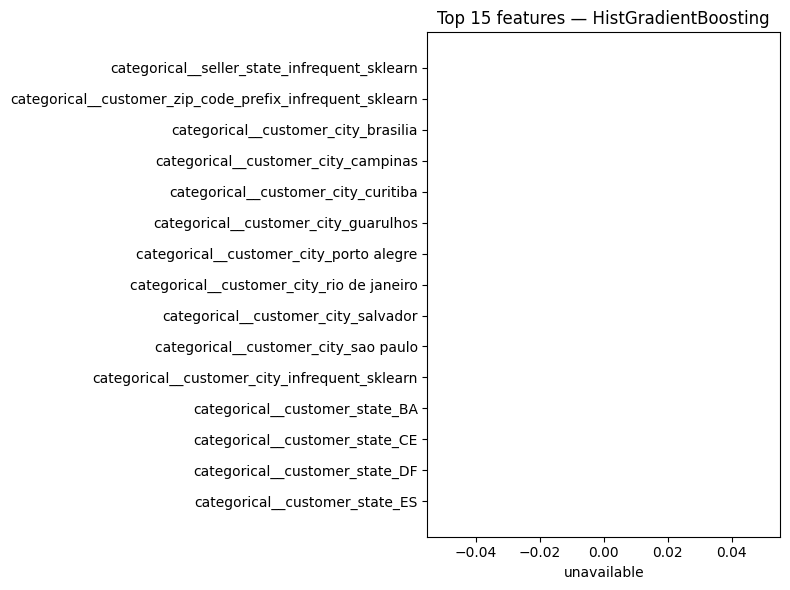

In [9]:
if hasattr(final_model, "feature_importances_"):
    importances = final_model.feature_importances_
    importance_kind = "feature_importances_"
elif hasattr(final_model, "coef_"):
    importances = np.abs(final_model.coef_[0])
    importance_kind = "abs(coef_)"
else:
    importances = np.zeros(len(feature_names))
    importance_kind = "unavailable"

top_n = 15
top_idx = np.argsort(importances)[::-1][:top_n]

print(f"Top {top_n} features by {importance_kind} ({final_model_family}):")
top_features = []
for rank, i in enumerate(top_idx, start=1):
    print(f"  {rank:>2}. {feature_names[i]:<40} {importances[i]:.4f}")
    top_features.append({"feature": feature_names[i], "importance": float(importances[i])})

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh([feature_names[i] for i in top_idx][::-1], [importances[i] for i in top_idx][::-1], color="#2b5c8f")
ax.set_xlabel(importance_kind)
ax.set_title(f"Top {top_n} features — {final_model_family}")
plt.tight_layout()
plt.show()


## 10. Optimize the Decision Threshold (Winning Model, Validation Only)

Model *selection* above used PR-AUC precisely because it doesn't depend on a
threshold. Now that the model is fixed, we separately pick an operating threshold —
the one that maximizes F1 on the validation split — purely for reporting a
concrete decision rule. This threshold does not feed back into which model was
selected in Section 7, so the search that chose the model can't be biased by
overfitting a threshold to validation noise.

Default threshold (0.50): validation F1 = 0.2492
Optimal threshold (0.5613): validation F1 = 0.2530


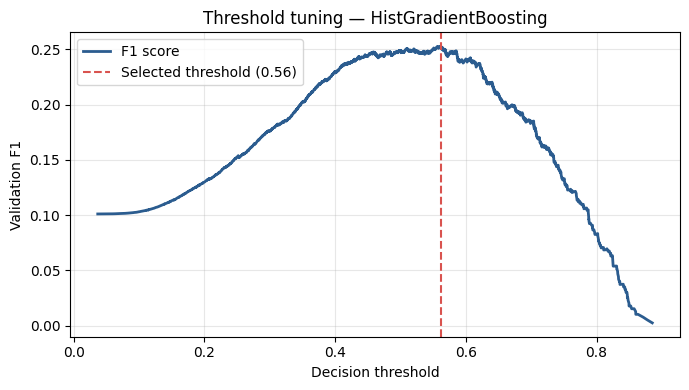

In [10]:
final_X_validation = X_validation_dense if final_uses_dense else X_validation
final_val_proba = final_model.predict_proba(final_X_validation)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_validation, final_val_proba)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
optimal_threshold = float(thresholds[best_idx])

default_f1 = f1_score(y_validation, (final_val_proba >= 0.5).astype(int))
tuned_f1 = f1_scores[best_idx]
print(f"Default threshold (0.50): validation F1 = {default_f1:.4f}")
print(f"Optimal threshold ({optimal_threshold:.4f}): validation F1 = {tuned_f1:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, f1_scores, color="#2b5c8f", lw=2, label="F1 score")
ax.axvline(optimal_threshold, color="#d9534f", linestyle="--", label=f"Selected threshold ({optimal_threshold:.2f})")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Validation F1")
ax.set_title(f"Threshold tuning — {final_model_family}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Final Evaluation on the Test Split (Touched Once)

This is the only section that reads `y_test` or scores against `X_test`. We report
metrics at both the default threshold (0.5) and the validation-tuned threshold, so
the test numbers can't be quietly cherry-picked after the fact — both are computed
in the same pass, once.

In [11]:
final_X_test = X_test_dense if final_uses_dense else X_test
test_proba = final_model.predict_proba(final_X_test)[:, 1]

test_default_metrics = evaluate(y_test, test_proba, threshold=0.5)
test_tuned_metrics = evaluate(y_test, test_proba, threshold=optimal_threshold)

print("Final model — TEST metrics @ threshold=0.50:")
for k, v in test_default_metrics.items():
    print(f"  {k:<18}: {v:.4f}")

print(f"\nFinal model — TEST metrics @ tuned threshold={optimal_threshold:.4f}:")
for k, v in test_tuned_metrics.items():
    print(f"  {k:<18}: {v:.4f}")

test_pred_default = (test_proba >= 0.5).astype(int)
test_pred_tuned = (test_proba >= optimal_threshold).astype(int)
cm_default = confusion_matrix(y_test, test_pred_default)
cm_tuned = confusion_matrix(y_test, test_pred_tuned)

print("\nConfusion matrix @ 0.50 (rows=actual, cols=predicted, [0=on-time, 1=late]):")
print(cm_default)
print(f"\nConfusion matrix @ {optimal_threshold:.4f} (rows=actual, cols=predicted, [0=on-time, 1=late]):")
print(cm_tuned)

# Read the numbers honestly: PR-AUC/ROC-AUC are threshold-independent and should be
# compared to validation and to the no-skill references above, not just eyeballed.
print(f"\nNo-skill PR-AUC reference (positive rate) — test: {y_test.mean():.4f}")
if test_tuned_metrics["roc_auc"] < 0.6:
    print("Note: test ROC-AUC is close to chance — treat this model's ranking as a weak")
    print("signal, not a reliable decision rule, regardless of how F1 looks at one threshold.")


Final model — TEST metrics @ threshold=0.50:
  average_precision : 0.0808
  roc_auc           : 0.5810
  f1                : 0.1123
  precision         : 0.0709
  recall            : 0.2699
  accuracy          : 0.7181

Final model — TEST metrics @ tuned threshold=0.5613:
  average_precision : 0.0808
  roc_auc           : 0.5810
  f1                : 0.0972
  precision         : 0.0659
  recall            : 0.1851
  accuracy          : 0.7729

Confusion matrix @ 0.50 (rows=actual, cols=predicted, [0=on-time, 1=late]):
[[10134  3382]
 [  698   258]]

Confusion matrix @ 0.5613 (rows=actual, cols=predicted, [0=on-time, 1=late]):
[[11008  2508]
 [  779   177]]

No-skill PR-AUC reference (positive rate) — test: 0.0661
Note: test ROC-AUC is close to chance — treat this model's ranking as a weak
signal, not a reliable decision rule, regardless of how F1 looks at one threshold.


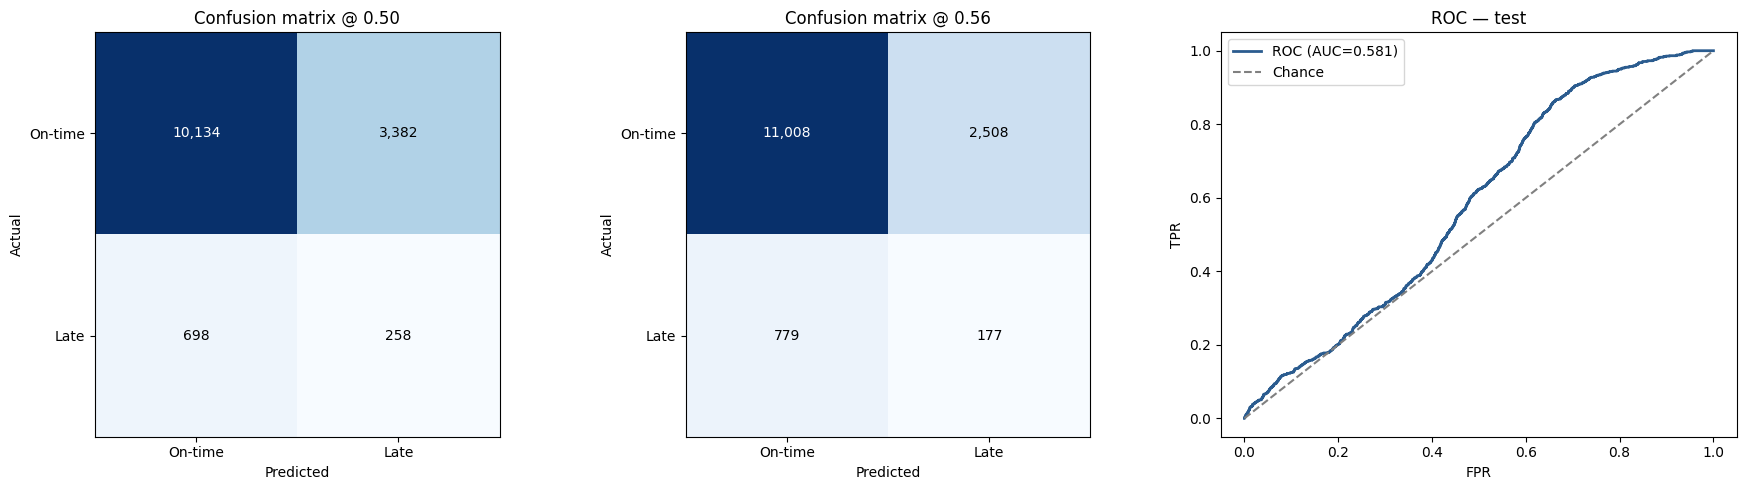

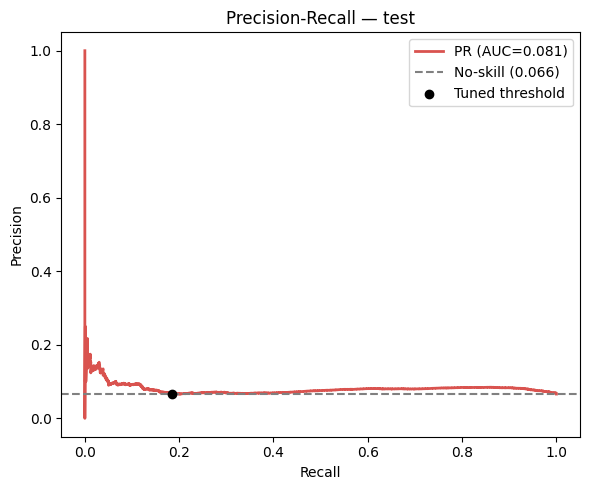

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in [
    (axes[0], cm_default, "Confusion matrix @ 0.50"),
    (axes[1], cm_tuned, f"Confusion matrix @ {optimal_threshold:.2f}"),
]:
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["On-time", "Late"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["On-time", "Late"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")

fpr, tpr, _ = roc_curve(y_test, test_proba)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, test_proba)
test_roc_auc = test_tuned_metrics["roc_auc"]
axes[2].plot(fpr, tpr, color="#2b5c8f", lw=2, label=f"ROC (AUC={test_roc_auc:.3f})")
axes[2].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
axes[2].set_title("ROC — test")
axes[2].set_xlabel("FPR"); axes[2].set_ylabel("TPR")
axes[2].legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
test_pr_auc = test_tuned_metrics["average_precision"]
ax.plot(rec_curve, prec_curve, color="#d9534f", lw=2, label=f"PR (AUC={test_pr_auc:.3f})")
ax.axhline(y_test.mean(), color="gray", linestyle="--", label=f"No-skill ({y_test.mean():.3f})")
ax.scatter([test_tuned_metrics["recall"]], [test_tuned_metrics["precision"]], color="black", zorder=5, label="Tuned threshold")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall — test")
ax.legend()
plt.tight_layout()
plt.show()


## 12. Persist Artifacts

In [13]:
baseline_model_path = artifact_dir / "baseline_model.joblib"
final_model_path = artifact_dir / "final_model.joblib"
results_path = artifact_dir / "results_summary.json"
tuning_csv_path = artifact_dir / "tuning_results.csv"

joblib.dump(baseline_model, baseline_model_path)
joblib.dump(final_model, final_model_path)
print(f"✓ Saved: {baseline_model_path.name}")
print(f"✓ Saved: {final_model_path.name}")

tuning_df = pd.DataFrame([
    {"family": r["family"], "params": json.dumps(r["params"]), **r["metrics"]}
    for r in tuning_results
]).sort_values(PRIMARY_METRIC, ascending=False)
tuning_df.to_csv(tuning_csv_path, index=False)
print(f"✓ Saved: {tuning_csv_path.name}")

results_summary = {
    "target": TARGET,
    "primary_metric": PRIMARY_METRIC,
    "train_positive_rate": float(train_pos_rate),
    "test_positive_rate": float(y_test.mean()),
    "baseline_model": "DummyClassifier(strategy='stratified')",
    "families_searched": sorted({r["family"] for r in tuning_results}),
    "n_candidates_evaluated": len(tuning_results),
    "final_model_family": final_model_family,
    "final_model_params": best_params,
    "final_model_uses_dense_input": final_uses_dense,
    "optimal_decision_threshold": optimal_threshold,
    "baseline_validation_metrics": baseline_val_metrics,
    "final_validation_metrics": final_val_metrics,
    "final_test_metrics_default_threshold": test_default_metrics,
    "final_test_metrics_tuned_threshold": test_tuned_metrics,
    "test_confusion_matrix_default_threshold": cm_default.tolist(),
    "test_confusion_matrix_tuned_threshold": cm_tuned.tolist(),
    "top_features": top_features,
    "n_features": len(feature_names),
    "known_limitations": [
        "Model selection (Section 7) used PR-AUC, which is threshold-independent; "
        "the decision threshold in Section 10 was tuned separately on validation "
        "and does not affect which model was chosen.",
        "If test ROC-AUC is markedly below validation ROC-AUC, treat that gap as a "
        "genuine finding (possible validation-set overfitting from the search itself, "
        "or train/test distribution shift) rather than noise.",
    ],
    "random_state": RANDOM_STATE,
}

with open(results_path, "w") as f:
    json.dump(results_summary, f, indent=2)
print(f"✓ Saved: {results_path.name}")


✓ Saved: baseline_model.joblib
✓ Saved: final_model.joblib
✓ Saved: tuning_results.csv
✓ Saved: results_summary.json


## 13. Artifact Reload Verification

A shape match alone doesn't prove a reloaded model is identical — we compare the
actual predicted probabilities on both validation and test.

In [14]:
loaded_final_model = joblib.load(final_model_path)

reload_val_check = loaded_final_model.predict_proba(final_X_validation)[:, 1]
np.testing.assert_allclose(reload_val_check, final_val_proba)

reload_test_check = loaded_final_model.predict_proba(final_X_test)[:, 1]
np.testing.assert_allclose(reload_test_check, test_proba)

print("✓ Verification successful: reloaded model reproduces identical validation and test predictions.")


✓ Verification successful: reloaded model reproduces identical validation and test predictions.


# Final Summary

Notebook 6 completed the following:

1. Loaded the preprocessed train/validation/test artifacts from Notebook 5.
2. Re-confirmed the class imbalance directly from the modeled arrays.
3. Chose average precision (PR-AUC) — threshold-independent — as the primary metric for model *selection*.
4. Trained a `DummyClassifier` baseline on train, scored on validation.
5. Searched **three model families** (Logistic Regression, Random Forest, Histogram
   Gradient Boosting), each tuned on train and scored on validation only, and picked
   the single best candidate across all of them by validation PR-AUC.
6. Confirmed the winner beats the baseline before going any further.
7. Separately tuned a deployment decision threshold (max-F1) on validation, without
   letting that choice influence which model was selected in step 5.
8. Touched the test split exactly once, reporting metrics at both 0.5 and the tuned
   threshold in the same pass.
9. Saved the baseline model, the final model, the full per-candidate tuning table,
   and a results summary — verified to reproduce identical predictions after reload.

### Main artifacts

- `artifacts/notebook_06/baseline_model.joblib`
- `artifacts/notebook_06/final_model.joblib`
- `artifacts/notebook_06/results_summary.json`
- `artifacts/notebook_06/tuning_results.csv`
